<a href="https://colab.research.google.com/github/hetpatel1812/MachineLearning-Track/blob/main/Day_17/Diabetes_Data_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")


Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.


In [3]:
import pandas as pd
df = pd.read_csv(path + "/diabetes.csv")

In [4]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [22]:
import numpy as np
col_zero = ['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[col_zero] = df[col_zero].replace(0, np.nan)
df[col_zero] = df[col_zero].replace(np.nan, df[col_zero].mean())

In [23]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.000000,148,72.000000,35.00000,155.548223,33.600000,0.627,50,1
1,1.000000,85,66.000000,29.00000,155.548223,26.600000,0.351,31,0
2,8.000000,183,64.000000,29.15342,155.548223,23.300000,0.672,32,1
3,1.000000,89,66.000000,23.00000,94.000000,28.100000,0.167,21,0
4,4.494673,137,40.000000,35.00000,168.000000,43.100000,2.288,33,1
5,5.000000,116,74.000000,29.15342,155.548223,25.600000,0.201,30,0
6,3.000000,78,50.000000,32.00000,88.000000,31.000000,0.248,26,1
7,10.000000,115,72.405184,29.15342,155.548223,35.300000,0.134,29,0
8,2.000000,197,70.000000,45.00000,543.000000,30.500000,0.158,53,1
9,8.000000,125,96.000000,29.15342,155.548223,32.457464,0.232,54,1


In [24]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y  =df['Outcome']

In [29]:
from numpy.random import RandomState
X_train, X_test , y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [46]:
model  = Sequential([
    Input(shape=(8,)),
    Dense(16,activation='relu'),
    Dense(8,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [47]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [48]:
history = model.fit(X_train,y_train ,
                    epochs=100,batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5560 - loss: 0.7054 - val_accuracy: 0.6260 - val_loss: 0.6579
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6986 - loss: 0.6823 - val_accuracy: 0.7398 - val_loss: 0.6496
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7271 - loss: 0.6665 - val_accuracy: 0.7236 - val_loss: 0.6429
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7312 - loss: 0.6513 - val_accuracy: 0.6992 - val_loss: 0.6345
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7291 - loss: 0.6350 - val_accuracy: 0.7236 - val_loss: 0.6219
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7312 - loss: 0.6145 - val_accuracy: 0.7236 - val_loss: 0.6049
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7230 - loss: 0.5912 - val_accuracy: 0.7317 - val_loss: 0.5839
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7230 - loss: 0.5648 - val_accuracy: 0.7073 - 

Text(0, 0.5, 'Accuracy')

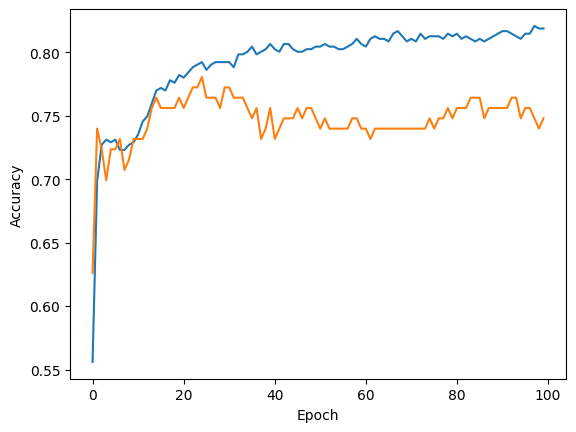

In [53]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

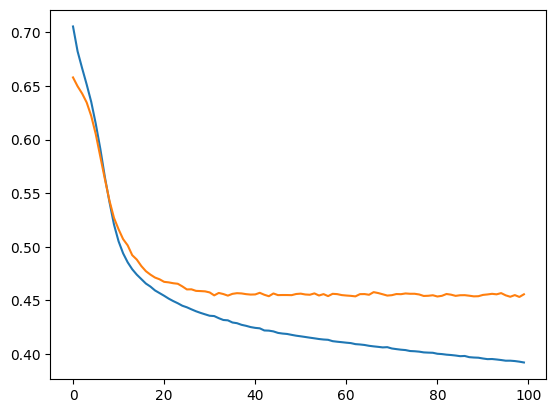

In [54]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')

In [50]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7208 - loss: 0.5351
Test Accuracy: 0.7208


In [51]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (model.predict(X_test) > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
[[76 23]
 [20 35]]
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        99
           1       0.60      0.64      0.62        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



In [57]:
# Input: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
user_data = np.array([[2, 138, 62, 35, 0, 33.6, 0.127, 47]])


prediction = model.predict(user_data_scaled)
result = "Diabetic" if prediction[0][0] > 0.5 else "Not Diabetic"
print(f"Prediction: {result} ({prediction[0][0]:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction: Not Diabetic (0.4559)
